# MOVIE SCREENCAPS !!!

woohoo! lets play with some movies! but as images!

## set up

In [1]:
# Some possible helper files from class

!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/audio_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [ ]:
# Some possible libraries.
# This isn't complete.

import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as PImage

from os import listdir, path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from data_utils import object_from_json_url, classification_error, display_confusion_matrix
from image_utils import get_pixels, make_image
from text_utils import get_top_words



In [38]:
from pathlib import Path
import re
import requests
import json

## data cleanup

accessing resize_images (where all the data is)

In [10]:
#load image data

base_path = Path("../resized_frames")

print(base_path)
print(base_path.exists())

print(Path.cwd())


../resized_frames
True
/Users/hwangw/Projects/ml_finalproject/msdvml_finalproject


In [11]:
for d in base_path.iterdir():
    print(d.name)
    for f in d.iterdir():
        print(f.name)
        break
    break

Meet Joe Black (1998)
frame_0955.jpg


In [ ]:
rows = []

for d in base_path.iterdir():
    if not d.is_dir():
        continue

    folder_name = d.name

    # extract movie + year
    match = re.match(r"(.+)\((\d{4})\)", folder_name)
    if match:
        movie_name = match.group(1).strip()
        year = int(match.group(2))
    else:
        movie_name = folder_name
        year = None

    for img_path in d.iterdir():
        if img_path.suffix.lower() not in [".jpg", ".png"]:
            continue

        # extract frame number
        frame_match = re.search(r"frame_(\d+)", img_path.name)
        frame_num = int(frame_match.group(1)) if frame_match else None

        rows.append({
            "filepath": str(img_path),
            "movie": movie_name,
            "year": year,
            "frame": frame_num
        })

df = pd.DataFrame(rows)

In [13]:
df = df.sort_values(by=["movie", "frame"], ascending=[True, True])
df.head(20)

,filepath,movie,year,frame
641970,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,0
642010,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,1
642071,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,2
642027,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,3
642186,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,4
642140,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,5
642079,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,6
642129,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,7
642755,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,8
642698,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,9


In [14]:
sorted(df["movie"].unique())

['10 Things I Hate About You',
 '12 Monkeys',
 '12 Years a Slave',
 '127 Hours',
 '13 Hours The Secret Soldiers Of Benghazi',
 '1917',
 '21 Grams',
 '25th Hour',
 '300',
 '310 to Yuma',
 '500 Days Of Summer',
 'A Beautiful Mind',
 'A Bronx Tale',
 'A Bugs Life',
 'A Few Good Men',
 'A Fish Called Wanda',
 'A Good Person',
 'A History of Violence',
 'A League of Their Own',
 'A Man Called Otto',
 'A Scanner Darkly',
 'A Serious Man',
 'A Single Man',
 'A Star Is Born',
 'A Time To Kill',
 'A Walk to Remember',
 'About Schmidt',
 'About Time',
 'About a Boy',
 'Across the Universe',
 'Adaptation',
 'Air',
 'Aladdin',
 'Aliens Special Edition',
 'Allied',
 'Almost Famous EXTENDED',
 'American Beauty',
 'American Gangster',
 'American History X',
 'American Hustle',
 'American Sniper',
 'An Education',
 'Anastasia',
 'Anchorman The Legend Of Ron Burgundy',
 'Apocalypto',
 'Apollo 13',
 'Argo',
 'Army of Darkness',
 'As Good as It Gets',
 'Atonement',
 'August Rush',
 'Austin Powers - Inter

In [15]:
df.shape
#rows #columns

(803907, 4)

now beefing up this data with tmdb_movies.csv. taken from netflix project from data visualizatino and information aesthetics class. (thank you daniel sauter and jonathan thirkield !). trying it out to see if I can cirucumvent needing to do API pulls to tmdb. (i cannot. forgot that project is just for the year... there are just so many movies in this world... wow)

In [28]:
tmdb_df = pd.read_csv("../tmdb_movies.csv")
tmdb_df.columns

Index(['Unnamed: 0', 'searched', 'tconst', 'Title', 'Available Globally?',
       'Date', 'Hours Viewed', 'Runtime', 'Views', 'Simple_Title', 'net_year',
       'titleType', 'primaryTitle', 'originalTitle', 'Release_Date',
       'runtimeMinutes', 'genres', 'rating', 'summary'],
      dtype='object')

beefing through api now tmdb

In [29]:
movies = df[["movie", "year"]].drop_duplicates()
movies.head()

,movie,year
641970,10 Things I Hate About You,1999.0
359963,12 Monkeys,1995.0
235985,12 Years a Slave,2013.0
167025,127 Hours,2010.0
377966,13 Hours The Secret Soldiers Of Benghazi,2016.0


In [ ]:
from keys import API_KEY

In [ ]:
BASE = "https://api.themoviedb.org/3"

r = requests.get(
    f"{BASE}/configuration",
    params={"api_key": API_KEY}
)
print(r.status_code)

200


In [ ]:
def get_tmdb_id(title, year):
    r = requests.get(
        "https://api.themoviedb.org/3/search/movie",
        params={
            "api_key": API_KEY,
            "query": title,
            "year": year
        }
    ).json()

    return r["results"][0]["id"] if r["results"] else None

In [46]:
def get_movie_info(movie_id):
    r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}",
        params={"api_key": API_KEY}
    ).json()

    return {
        "tmdb_id": movie_id,
        "summary": r.get("overview"),
        "genres": [g["name"] for g in r.get("genres", [])],
        "original_language": r.get("original_language"),
        "production_countries": [c["name"] for c in r.get("production_countries", [])]
    }

    def get_keywords(movie_id):
        r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}/keywords",
        params={"api_key": API_KEY}
    ).json()

    return [k["name"] for k in r.get("keywords", [])]

    def get_imdb_id(movie_id):
        r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}/external_ids",
        params={"api_key": API_KEY}
    ).json()

    return r.get("imdb_id")

def get_tmdb_id(title, year):
    r = requests.get(
        "https://api.themoviedb.org/3/search/movie",
        params={
            "api_key": API_KEY,
            "query": title,
            "year": year
        }
    ).json()

    return r["results"][0]["id"] if r["results"] else None


In [67]:
movies = df[["movie", "year"]].drop_duplicates()

lookup = {}

for _, row in movies.iterrows():
    mid = get_tmdb_id(row["movie"], row["year"])
    
    if mid:
        lookup[(row["movie"], row["year"])] = get_full_movie(mid)
    else:
        lookup[(row["movie"], row["year"])] = None

df["tmdb"] = df.apply(lambda r: lookup.get((r["movie"], r["year"])), axis=1)

In [68]:
df["genres"] = df["tmdb"].apply(lambda x: x["genres"] if x else None)
df["summary"] = df["tmdb"].apply(lambda x: x["summary"] if x else None)
df["keywords"] = df["tmdb"].apply(lambda x: x["keywords"] if x else None)
df["imdb_id"] = df["tmdb"].apply(lambda x: x["imdb_id"] if x else None)
df["language"] = df["tmdb"].apply(lambda x: x["original_language"] if x else None)
df["countries"] = df["tmdb"].apply(lambda x: x["production_countries"] if x else None)

In [69]:
df.head()

,filepath,movie,year,frame,genres,summary,keywords,tconst,language,countries,tmdb,imdb_id
641970,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,0,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America],"{'tmdb_id': 4951, 'summary': 'On the first day...",tt0147800
642010,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,1,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America],"{'tmdb_id': 4951, 'summary': 'On the first day...",tt0147800
642071,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,2,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America],"{'tmdb_id': 4951, 'summary': 'On the first day...",tt0147800
642027,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,3,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America],"{'tmdb_id': 4951, 'summary': 'On the first day...",tt0147800
642186,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,4,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America],"{'tmdb_id': 4951, 'summary': 'On the first day...",tt0147800


In [70]:
#drop to clean up

df = df.drop(columns=["tmdb", "tconst"])

In [ ]:
df.head()

,filepath,movie,year,frame,genres,summary,keywords,language,countries,imdb_id
641970,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,0,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",en,[United States of America],tt0147800
642010,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,1,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",en,[United States of America],tt0147800
642071,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,2,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",en,[United States of America],tt0147800
642027,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,3,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",en,[United States of America],tt0147800
642186,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,4,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",en,[United States of America],tt0147800


In [80]:
from IPython.display import display, HTML

display(HTML(
    df.drop_duplicates(subset=["movie", "year"])[
        ["movie", "year", "genres", "summary", "imdb_id"]
    ].to_html(max_rows=10)
))

,movie,year,genres,summary,imdb_id
641970,10 Things I Hate About You,1999.0,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron instantly falls for Bianca, the gorgeous girl of his dreams. The only problem is that Bianca is forbidden to date until her ill-tempered, completely un-dateable older sister Kat goes out, too. In an attempt to solve his problem, Cameron singles out the only guy who could possibly be a match for Kat: a mysterious bad boy with a nasty reputation of his own.",tt0147800
359963,12 Monkeys,1995.0,"[Science Fiction, Thriller, Mystery]","In the year 2035, convict James Cole reluctantly volunteers to be sent back in time to discover the origin of a deadly virus that wiped out nearly all of the earth's population and forced the survivors into underground communities. But when Cole is mistakenly sent to 1990 instead of 1996, he's arrested and locked up in a mental hospital. There he meets psychiatrist Dr. Kathryn Railly and the son of a famous virus expert who may hold the key to the Army of the 12 Monkeys; thought to be responsible for unleashing the killer disease.",tt0114746
235985,12 Years a Slave,2013.0,"[Drama, History]","In the pre-Civil War United States, Solomon Northup, a free black man from upstate New York, is abducted and sold into slavery. Facing cruelty as well as unexpected kindnesses Solomon struggles not only to stay alive, but to retain his dignity. In the twelfth year of his unforgettable odyssey, Solomon’s chance meeting with a Canadian abolitionist will forever alter his life.",tt2024544
167025,127 Hours,2010.0,"[Adventure, Drama, Thriller]",The true story of mountain climber Aron Ralston's remarkable adventure to save himself after a fallen boulder crashes on his arm and traps him in an isolated canyon in Utah.,tt1542344
377966,13 Hours The Secret Soldiers Of Benghazi,2016.0,"[War, Action, History, Drama, Thriller]",An American Ambassador is killed during an attack at a U.S. compound in Libya as a security team struggles to make sense out of the chaos.,tt4172430
...,...,...,...,...,...
674977,Zack Snyders Justice League,2021.0,"[Action, Adventure, Fantasy]","Determined to ensure Superman's ultimate sacrifice was not in vain, Bruce Wayne aligns forces with Diana Prince with plans to recruit a team of metahumans to protect the world from an approaching threat of catastrophic proportions.",tt12361974
175025,Zero Dark Thirty,2012.0,"[Thriller, Drama]","A chronicle of the decade-long hunt for al-Qaeda terrorist leader Osama bin Laden after the September 2001 attacks, and his death at the hands of the Navy S.E.A.L. Team 6 in May, 2011.",tt1790885
703981,Zodiac,2007.0,"[Crime, Mystery, Thriller]","Over the course of a decade, editors of the San Francisco Chronicle entice themselves in the murders of the Zodiac Killer. However, as time runs its course, interest in the case dwindles in the eyes of the professionals. The Killer stops interacting with the public. However, believing he has the answers, an amateur cartoonist from the initial sightings races against time to prevent what he believes is another murder.",tt0443706
398967,Zootopia,2016.0,"[Animation, Adventure, Family, Comedy]","Determined to prove herself, Officer Judy Hopps, the first bunny on Zootopia's police force, jumps at the chance to crack her first case - even if it means partnering with scam-artist fox Nick Wilde to solve the mystery.",tt2948356


I have all of this info organized in a dataframe now. Keeping some of the text keywords stuff just in case I want to use it later. (Text Analysis). For now, working with image information and genre mostly! Goal is to get it working before hitting more reach goals. 

## image analysis stuff

goal is to: do 1 before do all !

In [92]:
from Homework07_utils import CamUtils

ModuleNotFoundError: No module named 'Homework07_utils'

In [86]:
movie_images = df[df["movie"] == "10 Things I Hate About You"]["filepath"].tolist()

print(len(movie_images))
print(movie_images[:5])

1000
['../resized_frames/10 Things I Hate About You (1999)/frame_0000.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0001.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0002.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0003.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0004.jpg']


In [90]:
movie_files = (
    df[df["movie"] == "10 Things I Hate About You"]
    .sort_values("frame")["filepath"]
    .tolist()
)

print(movie_files)

['../resized_frames/10 Things I Hate About You (1999)/frame_0000.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0001.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0002.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0003.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0004.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0005.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0006.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0007.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0008.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0009.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0010.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0011.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0012.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0013.jpg', '../resized_frames/

In [98]:
print(len(movie_files))
print(movie_files[:3])

1000
['../resized_frames/10 Things I Hate About You (1999)/frame_0000.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0001.jpg', '../resized_frames/10 Things I Hate About You (1999)/frame_0002.jpg']


In [95]:
pixel_data = []
label_data = []

for movie_image in movie_files:
    img = PImage.open(movie_image)

    pixel_data.append(get_pixels(img))

    label = df[df["filepath"] == movie_image]["movie"].values[0]
    label_data.append(label)


In [99]:
print(len(pixel_data))
print(len(label_data))

1000
1000


In [ ]:
pixel_data = []

for path in movie_files:
    img = PImage.open(path)

    w, h = img.size
    new_h = 256

    img = img.resize((w, new_h))

    pixel_data.append(((w, new_h), list(img.getdata())))

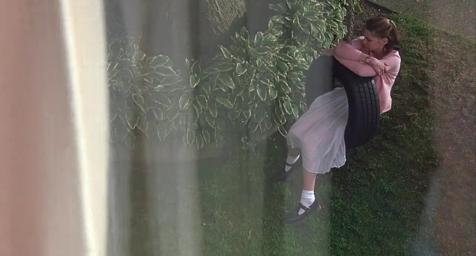

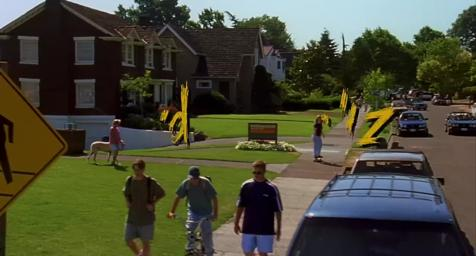

In [114]:
img = PImage.new("RGB", pixel_data[800][0])
img.putdata(pixel_data[800][1])
display(img)

img = PImage.new("RGB", pixel_data[10][0])
img.putdata(pixel_data[10][1])
display(img)